105380 distinct particles, average size range: 1.33 to 3.76 px

Fitted peaks: small = 2.41 px (std 0.24), big = 2.92 px (std 0.17)
Data-driven decision boundary (valley): 2.57 px

Implied microns-per-pixel from small peak: 0.3529
Implied microns-per-pixel from big peak:   0.3939

Saved size histogram to:
  /Volumes/Expansion/recordings/size_histogram.png

Classified 90975 big particles, 14405 small particles.
Saved classified trajectories to:
  /Volumes/Expansion/recordings/linked_trajectories_classified.csv


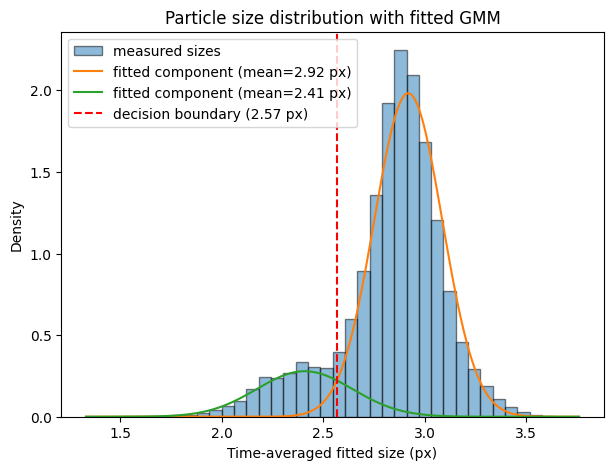

In [1]:
"""
classify_by_size.py

Step 4 of the glass pipeline: classify each tracked particle as "big"
or "small" based on its time-averaged fitted size (trackpy's per-frame
`size` output, averaged over every frame that particle appears in).

Averaging over time (rather than trusting a single frame) is more
robust -- any one frame's size fit can be noisy (partial occlusion,
slight defocus), but the average over many frames converges to a
stable estimate of the particle's true size.

THRESHOLD METHOD: originally this converted the known nominal particle
diameters (1.7 um, 2.3 um) to pixels via MICRONS_PER_PIXEL and used the
midpoint as the threshold. That produced a threshold that did NOT sit
in the histogram's valley -- a sign MICRONS_PER_PIXEL (inherited from
a different rig/notebook, 0.3262 um/px) is likely wrong for this video.

Fix: instead of relying on a possibly-wrong physical conversion, we fit
a two-component Gaussian Mixture Model directly to the measured pixel
sizes. This finds the two peaks AND the decision boundary between them
purely from the data's own shape -- no MICRONS_PER_PIXEL needed for
classification at all. As a bonus, once we have the two fitted peak
centers (in px) and we already know the true physical radii (0.85 um,
1.15 um), we can back out a corrected MICRONS_PER_PIXEL for use
elsewhere in the pipeline (density, MSD) -- reported at the end, not
used for the classification itself.

Input:  linked_trajectories.csv from detect_and_link.py
Output: same dataframe with a new "class" column ("big"/"small"),
        plus a histogram plot showing the fitted Gaussians and the
        data-derived decision boundary.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ----------------------------------------------------------------------
# 1. CONFIG -- edit these values
# ----------------------------------------------------------------------

INPUT_CSV = "/Volumes/Expansion/recordings/linked_trajectories.csv"   # <-- fill in: path to linked_trajectories.csv
OUTPUT_DIR = os.path.dirname(INPUT_CSV)  # <-- fill in: folder to save outputs into

# known physical radii, used only to back out a corrected pixel scale
# AFTER fitting -- not used to set the classification threshold itself
RADIUS_SMALL_UM = 1.7 / 2
RADIUS_BIG_UM = 2.3 / 2


def find_decision_boundary(gmm, x_min, x_max, n_points=2000):
    """
    Find where the two fitted Gaussian components (weighted by their
    mixture weights) cross -- i.e. where a particle is equally likely
    to belong to either population. This is the data-driven "valley,"
    and isn't necessarily the exact midpoint between the two means if
    the components have different spreads or weights.
    """
    xs = np.linspace(x_min, x_max, n_points).reshape(-1, 1)
    resp = gmm.predict_proba(xs)  # (n_points, 2) responsibility for each component
    # boundary is where responsibility for the two components crosses 0.5
    diff = resp[:, 0] - resp[:, 1]
    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(sign_changes) == 0:
        # fallback: components didn't cross in this range, use midpoint of means
        return float(np.mean(gmm.means_))
    idx = sign_changes[0]
    return float(xs[idx, 0])


def main():
    if INPUT_CSV is None or OUTPUT_DIR is None:
        raise ValueError("Set INPUT_CSV and OUTPUT_DIR before running.")

    df = pd.read_csv(INPUT_CSV)
    if "size" not in df.columns:
        raise ValueError(
            "No 'size' column found -- this should come from trackpy.locate's "
            "output. Check that detect_and_link.py saved it into the CSV."
        )

    # ------------------------------------------------------------------
    # 2. Average measured size per particle (across all its frames)
    # ------------------------------------------------------------------

    avg_size_per_particle = df.groupby("particle")["size"].mean()
    sizes = avg_size_per_particle.values.reshape(-1, 1)
    print(f"{len(avg_size_per_particle)} distinct particles, "
          f"average size range: {avg_size_per_particle.min():.2f}"
          f" to {avg_size_per_particle.max():.2f} px")

    # ------------------------------------------------------------------
    # 3. Fit a 2-component Gaussian Mixture Model directly to the data
    # ------------------------------------------------------------------

    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(sizes)

    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    # order components small -> big
    order = np.argsort(means)
    mean_small_px, mean_big_px = means[order]
    std_small_px, std_big_px = stds[order]

    threshold_px = find_decision_boundary(
        gmm, avg_size_per_particle.min(), avg_size_per_particle.max()
    )

    print(f"\nFitted peaks: small = {mean_small_px:.2f} px "
          f"(std {std_small_px:.2f}), big = {mean_big_px:.2f} px "
          f"(std {std_big_px:.2f})")
    print(f"Data-driven decision boundary (valley): {threshold_px:.2f} px")

    # ------------------------------------------------------------------
    # 4. Bonus: back out a corrected microns-per-pixel from the fit,
    #    for use elsewhere in the pipeline (NOT used for classification)
    # ------------------------------------------------------------------

    scale_from_small = RADIUS_SMALL_UM / mean_small_px
    scale_from_big = RADIUS_BIG_UM / mean_big_px
    print(f"\nImplied microns-per-pixel from small peak: {scale_from_small:.4f}")
    print(f"Implied microns-per-pixel from big peak:   {scale_from_big:.4f}")
    if abs(scale_from_small - scale_from_big) / scale_from_small > 0.1:
        print("WARNING: these two estimates disagree by >10% -- "
              "worth double-checking before trusting either.")
    else:
        corrected_scale = (scale_from_small + scale_from_big) / 2
        print(f"Average corrected MICRONS_PER_PIXEL estimate: "
              f"{corrected_scale:.4f} (use this in later steps, e.g. MSD/density)")

    # ------------------------------------------------------------------
    # 5. Histogram with fitted Gaussians and decision boundary overlaid
    # ------------------------------------------------------------------

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(avg_size_per_particle, bins=40, density=True,
            edgecolor="black", alpha=0.5, label="measured sizes")

    xs = np.linspace(avg_size_per_particle.min(), avg_size_per_particle.max(), 500)
    for i, (m, s) in enumerate(zip(means, stds)):
        weight = gmm.weights_[i]
        pdf = weight * (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - m) / s) ** 2)
        ax.plot(xs, pdf, label=f"fitted component (mean={m:.2f} px)")

    ax.axvline(threshold_px, color="red", linestyle="--",
               label=f"decision boundary ({threshold_px:.2f} px)")
    ax.set_xlabel("Time-averaged fitted size (px)")
    ax.set_ylabel("Density")
    ax.set_title("Particle size distribution with fitted GMM")
    ax.legend()
    hist_path = os.path.join(OUTPUT_DIR, "size_histogram.png")
    fig.savefig(hist_path, dpi=150, bbox_inches="tight")
    print(f"\nSaved size histogram to:\n  {hist_path}")

    # ------------------------------------------------------------------
    # 6. Classify and save
    # ------------------------------------------------------------------

    labels = gmm.predict(sizes)  # 0 or 1, per particle, in original order
    # map whichever component index corresponds to the smaller mean -> "small"
    small_component_idx = order[0]
    classification = pd.Series(
        np.where(labels == small_component_idx, "small", "big"),
        index=avg_size_per_particle.index,
    )

    df["class"] = df["particle"].map(classification)

    n_big = (classification == "big").sum()
    n_small = (classification == "small").sum()
    print(f"\nClassified {n_big} big particles, {n_small} small particles.")

    output_csv = os.path.join(OUTPUT_DIR, "linked_trajectories_classified.csv")
    df.to_csv(output_csv, index=False)
    print(f"Saved classified trajectories to:\n  {output_csv}")


if __name__ == "__main__":
    main()